This notebook demonstrates traditional image blurring (uniform and Gaussian), custom 2D convolution for sharpening, and exploration of adaptive blurring and sharpening techniques.

In [2]:
import numpy as np
import cv2 as cv
from matplotlib import pyplot as plt
from skimage import io

Loading an image and displaying its attributes

In [3]:
#img = io.imread('https://img.freepik.com/free-photo/girl-plays-with-sand-sahara-desert-erg-chebbi-merzouga-morocco_129479-355.jpg')
#img = io.imread('https://www.cartacapital.com.br/wp-content/uploads/2020/10/000_8UA32F-1024x683.jpg')
!wget https://www.cartacapital.com.br/wp-content/uploads/2020/10/000_8UA32F-1024x683.jpg
img = io.imread('000_8UA32F-1024x683.jpg')
print(img.shape)
print(img.dtype)

--2025-11-21 22:50:57--  https://www.cartacapital.com.br/wp-content/uploads/2020/10/000_8UA32F-1024x683.jpg
Resolvendo www.cartacapital.com.br (www.cartacapital.com.br)... 2606:4700:20::681a:8b7, 2606:4700:20::ac43:48df, 2606:4700:20::681a:9b7, ...
Conectando-se a www.cartacapital.com.br (www.cartacapital.com.br)|2606:4700:20::681a:8b7|:443... conectado.
A requisição HTTP foi enviada, aguardando resposta... 200 OK
Tamanho: 105881 (103K) [image/jpeg]
Salvando em: ‘000_8UA32F-1024x683.jpg’

000_8UA32F-1024x683 100%[===================>] 103,40K  --.-KB/s    em 0,01s   

2025-11-21 22:50:57 (9,27 MB/s) - ‘000_8UA32F-1024x683.jpg’ salvo [105881/105881]

(683, 1024, 3)
uint8


Visualizing the image

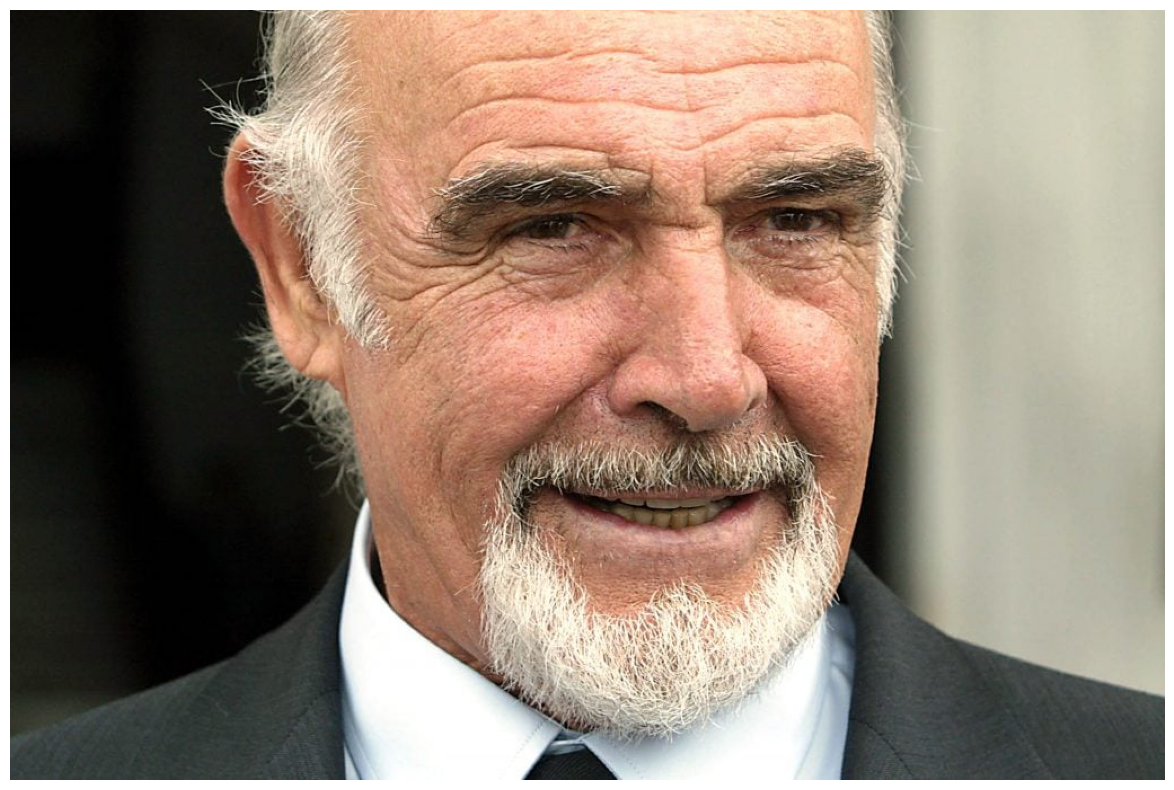

In [4]:
plt.figure(figsize=(15, 10))
plt.imshow(img)
plt.axis('off')
plt.show()

Comparing traditional blur (uniform weight mask) with gaussian blur (weights from Gaussian function)

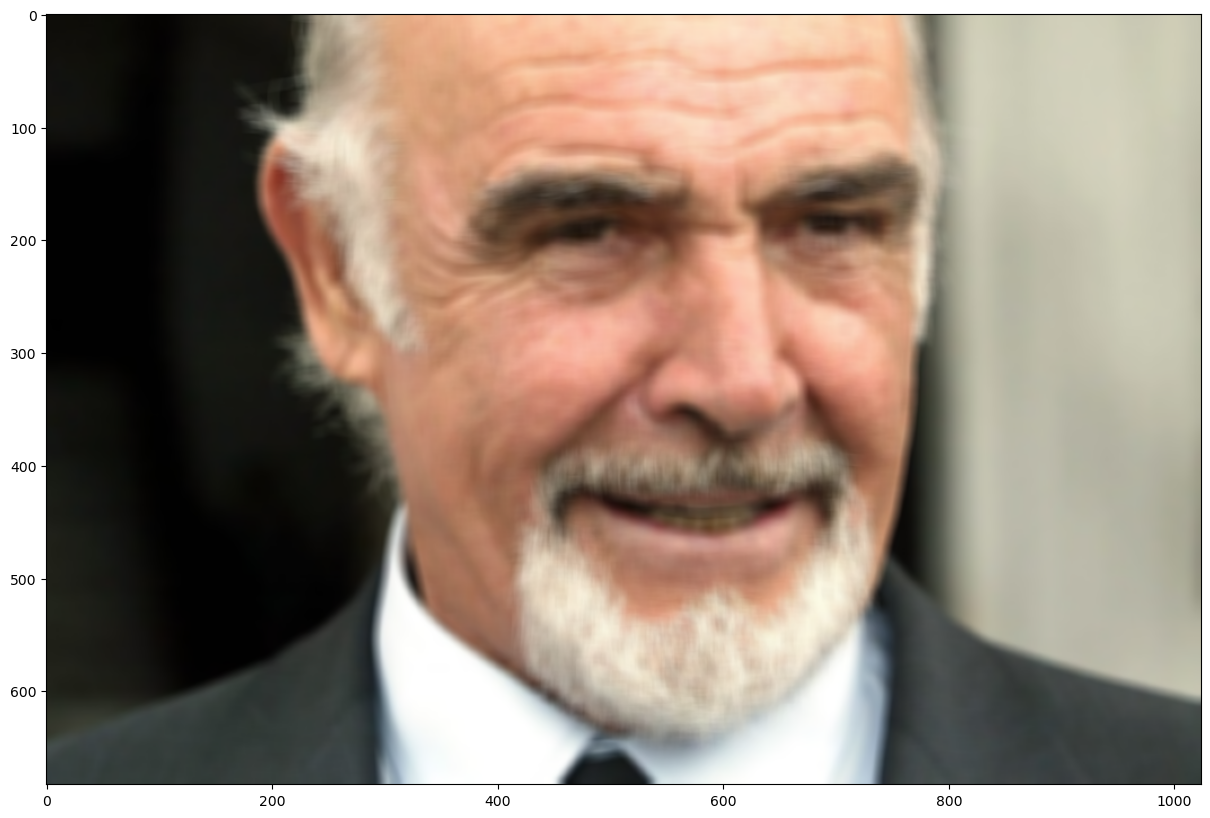

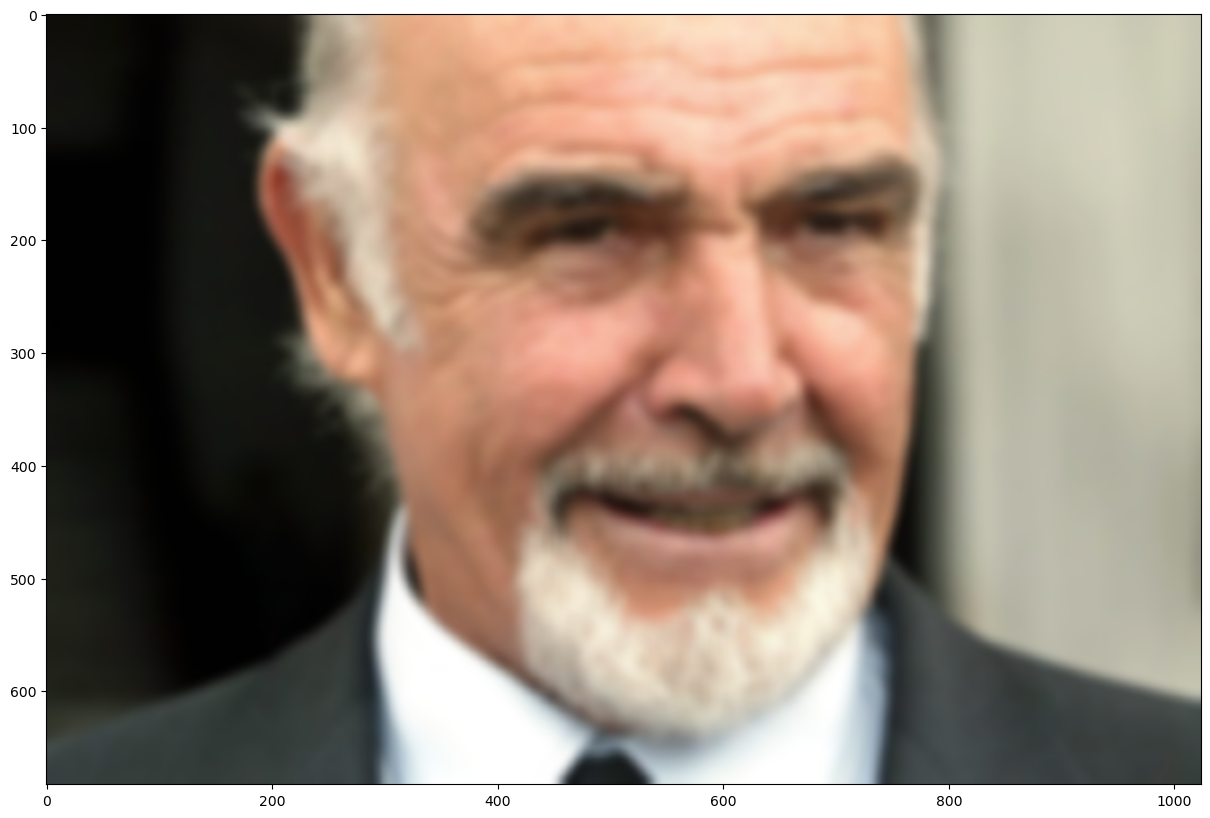

(683, 1024, 3)


In [5]:
plt.figure(figsize=(15, 10))
blur1 = cv.blur(img,(11,11))
plt.imshow(blur1)
plt.show()

plt.figure(figsize=(15, 10))
blur2 = cv.blur(blur1,(11,11))
plt.imshow(blur2)
plt.show()

print(blur2.shape)


Performing a 2D convolution using a custom mask (sharpening) and showing original and resulting images

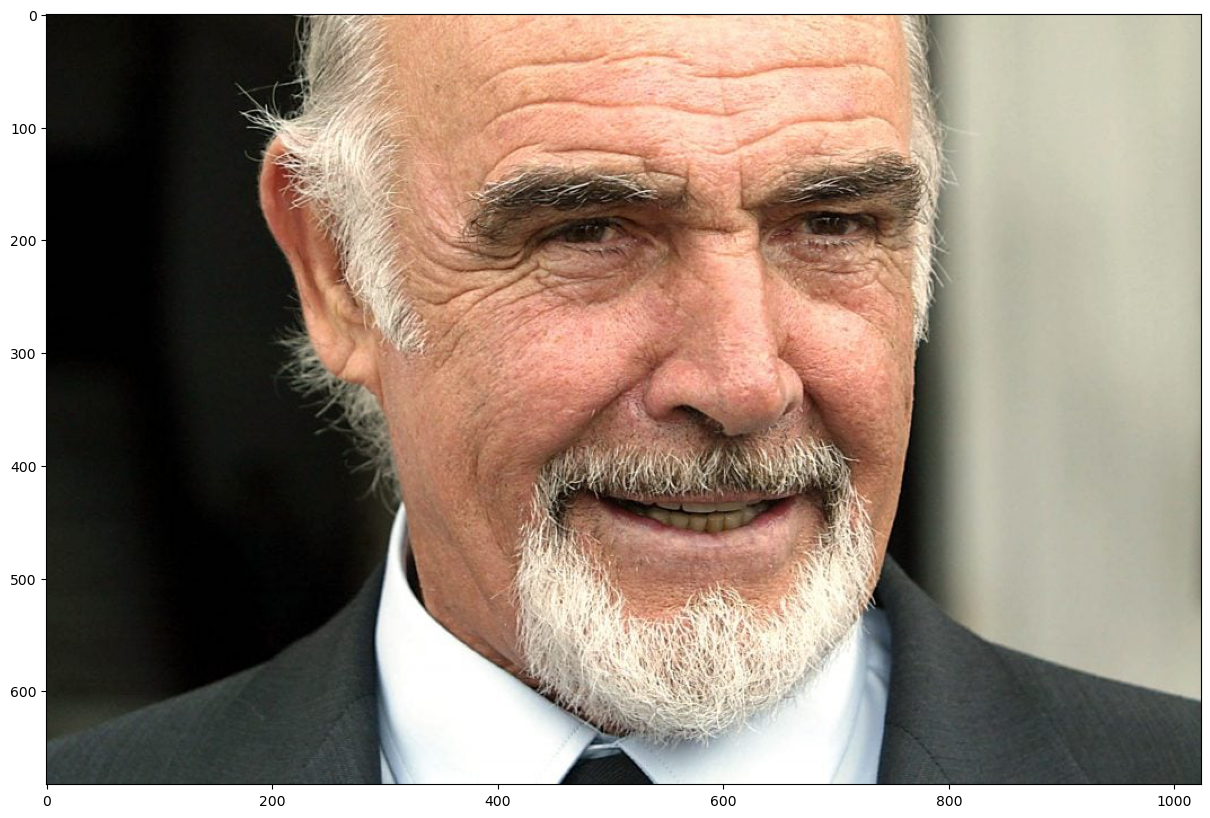

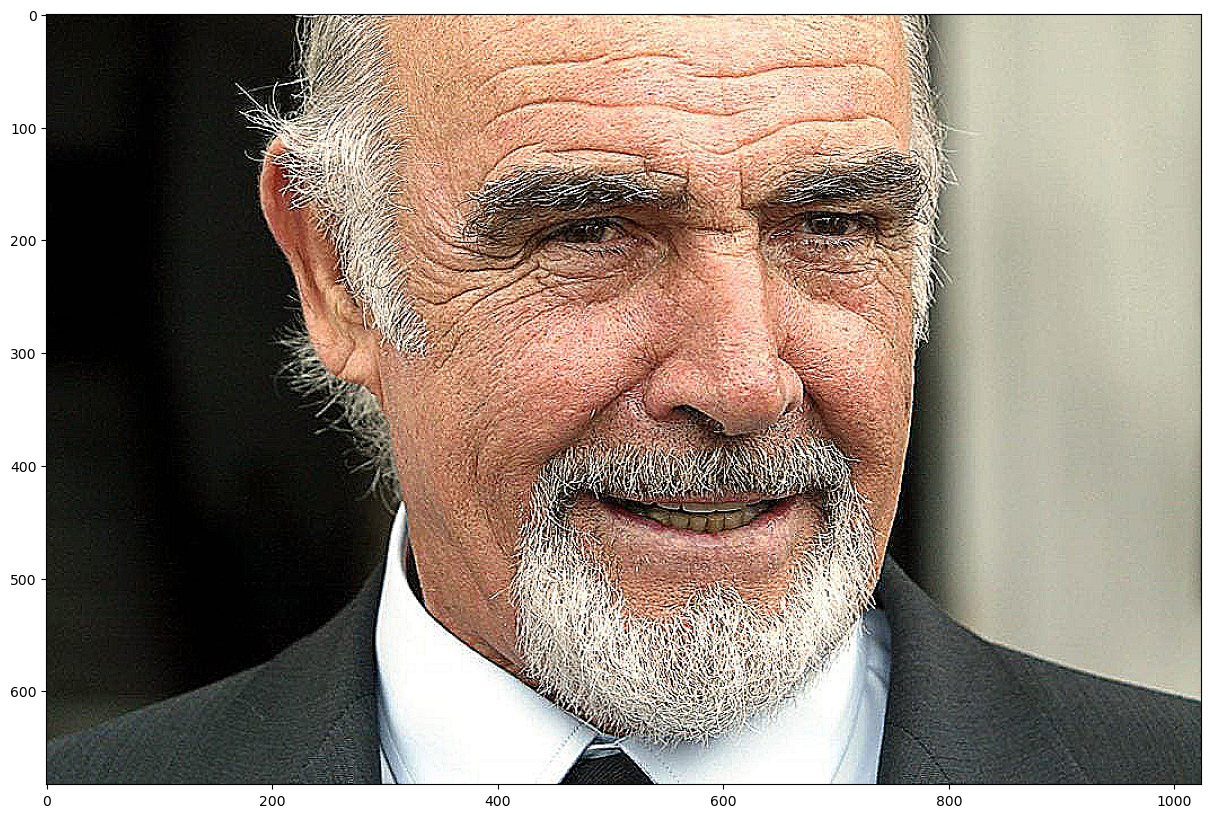

In [6]:
plt.figure(figsize=(15, 10))

mask = np.array([[0, -2, 0],
                 [-2, 9, -2],
                 [0, -2, 0]])

result = cv.filter2D(img,-1,mask)
plt.imshow(img)
plt.show()

plt.figure(figsize=(15, 10))

plt.imshow(result)
plt.show()

Inspecting type of resulting image:

In [7]:
result.dtype

dtype('uint8')

Let's try different convolution masks.

How about designing convolution masks for detecting:
* vertical lines
* horizontal lines



Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].


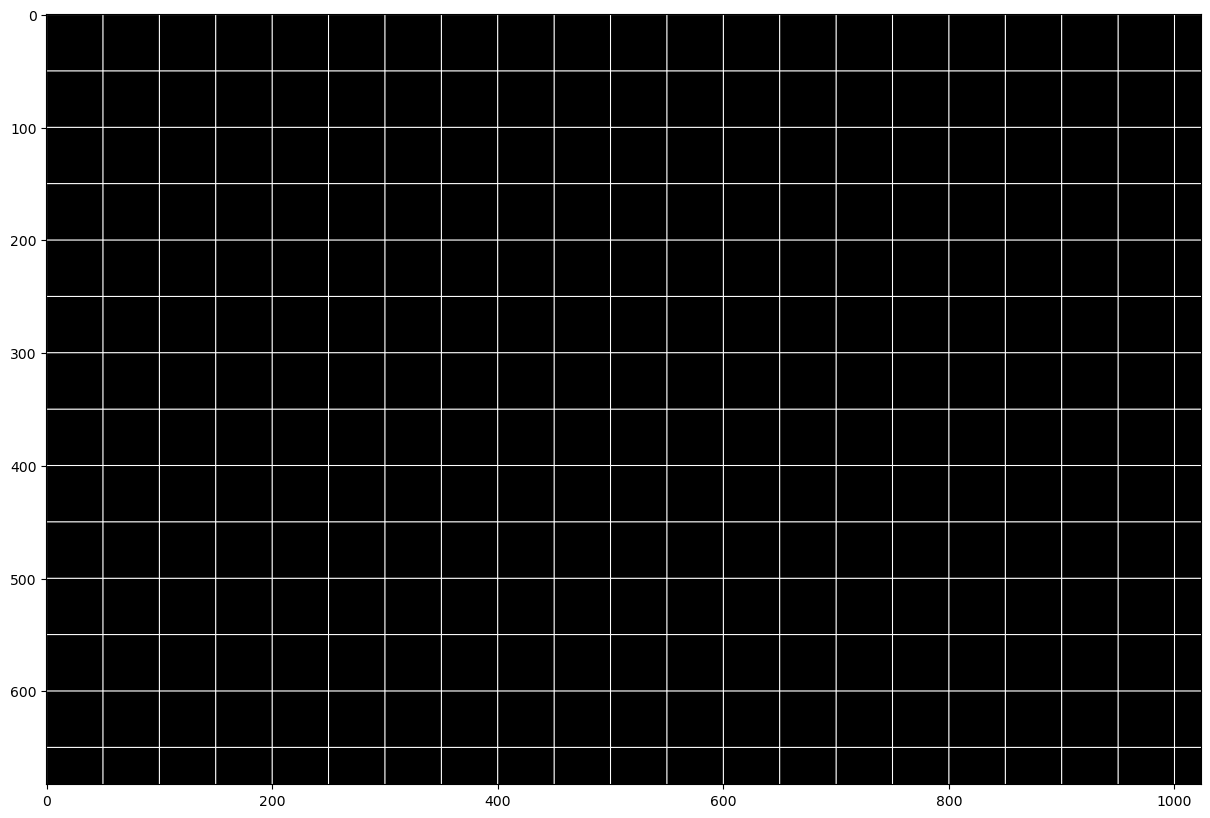

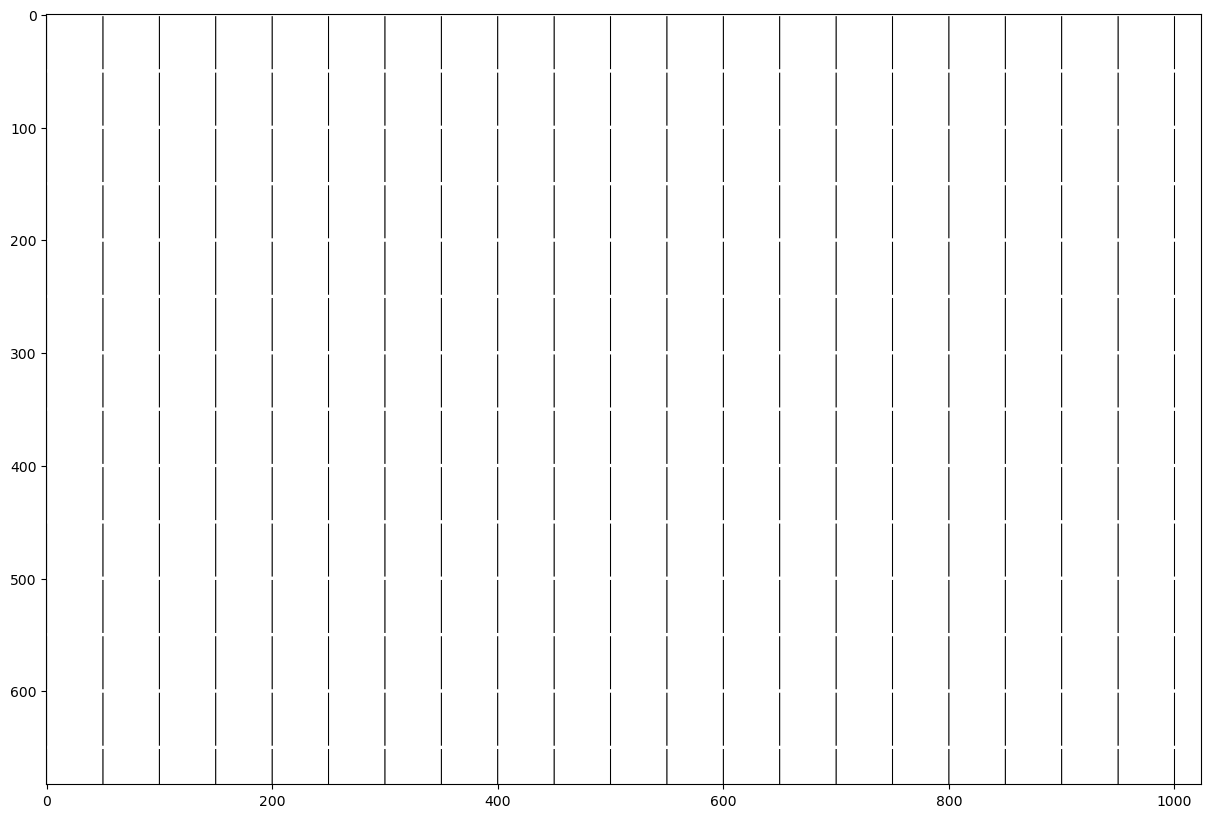

765.0 -765.0


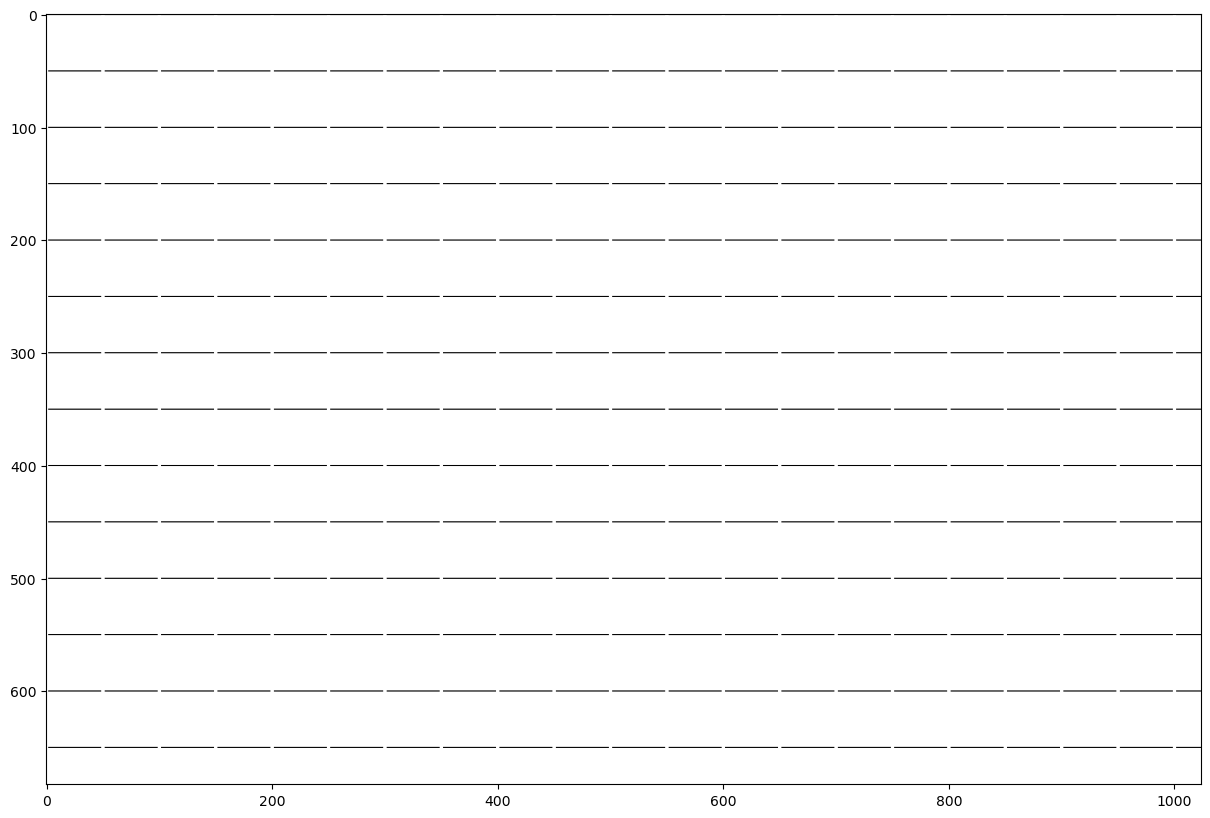

765.0 -765.0


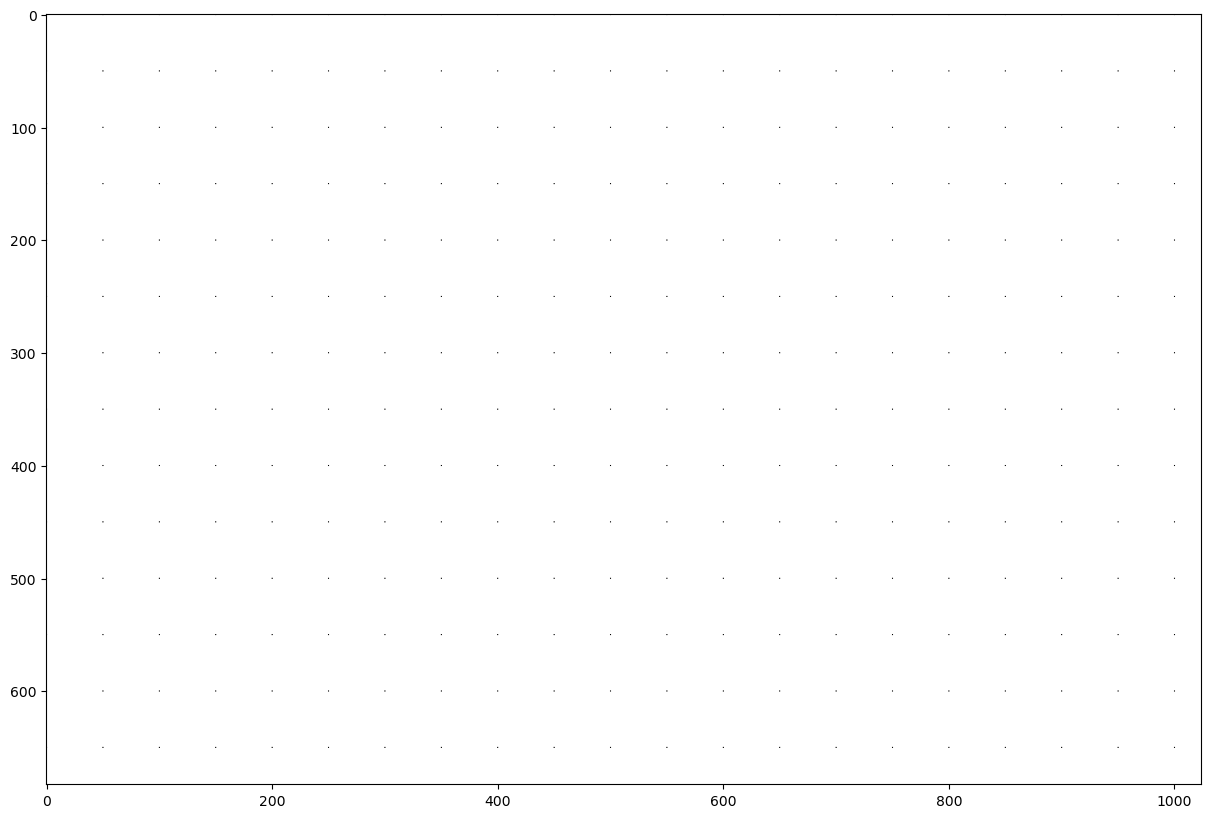

1275.0 -255.0


In [8]:
mask_vert = np.array([ [-1,   1,  -1],
                       [ -1,  1,  -1],
                       [-1,   1, -1]])

mask_horz = np.array([ [-1,  -1,  -1],
                       [ 1,  1,  1],
                       [-1,  -1, -1]])

mask_cross = np.array([ [-1,  1,  -1],
                       [  1,  1,   1],
                       [ -1,  1,  -1]])

new_img = np.zeros(img.shape)
y_size=new_img.shape[0]
x_size=new_img.shape[1]
new_img[0:y_size:50, 0:x_size]=255
new_img[0:y_size, 0:x_size:50]=255

plt.figure(figsize=(15, 10))
plt.imshow(new_img)
plt.show()

filters=[(mask_vert,600),(mask_horz,600), (mask_cross,800)]

for f,th in filters:
  result = cv.filter2D(new_img,-1,f)
  plt.figure(figsize=(15, 10))
  plt.imshow(result[:,:,0]<th,cmap='gray' )
  plt.show()
  print(np.max(result), np.min(result))

# Now is your turn.
Based on the following code:

1. Create your improved 2D convolution that performs an adaptive blur (blur
occurs only on local areas with low standard deviation). Choose an approriate mask size to create a visible smoothing effect on the skin.  Run your code on the same input color image shown at the begining of this notebook.

2. Create your improved 2D convolution that performs an adaptive sharpening (sharpening occurs only on local areas with high standard variation). Choose an approriate mask size to create a visible sharpening effect on the face area. Run your code on the same input color image shown at the begining of this notebook.

3. Use the original image to perform adaptive blur followed by adaptive shapening and vice-versa. Any differences in the results? Please comment on that.

Start with implementing the 2D convolution operation from scratch for a NxN blur operation.
Then include the needed tests and auxiliary functions to perform the adaptive blur and sharpening. Finally, include code to perform the required tests and add some comments about the obtained results.


## Questão 1:

(341, 512, 3)


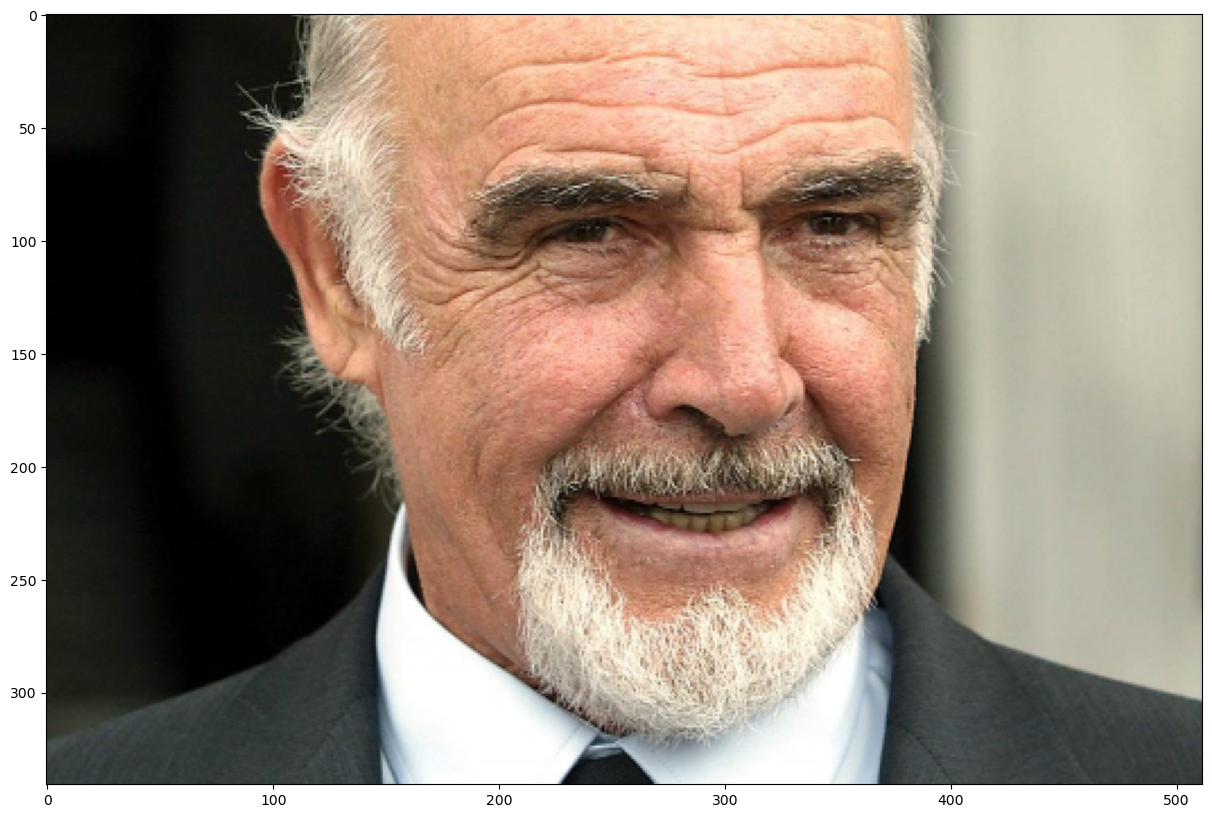

In [9]:
#resize the image to reduce computation costs
img = cv.resize(img,(int(img.shape[1]/2),int(img.shape[0]/2)))
print(img.shape)
#display the resulting image
plt.figure(figsize=(15, 10))
plt.imshow(img)
plt.show()

In [10]:
mask_size = 5
mask = np.ones((mask_size,mask_size))
mask = mask/(sum(mask)*sum(mask))
print(mask)


[[0.04 0.04 0.04 0.04 0.04]
 [0.04 0.04 0.04 0.04 0.04]
 [0.04 0.04 0.04 0.04 0.04]
 [0.04 0.04 0.04 0.04 0.04]
 [0.04 0.04 0.04 0.04 0.04]]


In [11]:
#calculates de standard deviation of an image crop
#def calc_std(img_crop):
#...
def calc_std(img_crop):
  std = np.std(img_crop)
  return std

In [12]:
def adaptive_blur(mask_size, img, mask, threshold):

  img_blurred_cv = cv.filter2D(img, -1, mask)
  result = np.zeros(img.shape)
  tot_lin = img.shape[0]
  tot_col = img.shape[1]
  for color in range(0,3):
    for lin in range(mask_size-1,tot_lin):
      for col in range(mask_size-1,tot_col):
        img_crop = img[lin-mask_size:lin, col-mask_size:col, color]
        if calc_std(img_crop) > threshold: #do not perform convolution
           result[lin,col,color]  = img[lin,col,color]
        else: # perform convolution
          result[lin,col,color] = img_blurred_cv[lin,col,color]
  result = result.astype(np.uint8)
  return result

Comentário: Criamos uma função para o blur adaptativo com filtro 2D de convolução. Estamos preservando as bordas (onde o desvio padrão é alto, como na barba e cabelos) e suavizando áreas lisas (como a pele da testa)

In [13]:
# Faz o teste com blur adapatativo
img_blurred = adaptive_blur(mask_size, img, mask, 10)

/home/orlando/miniconda3/lib/python3.13/site-packages/numpy/core/_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/orlando/miniconda3/lib/python3.13/site-packages/numpy/core/_methods.py:163: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/home/orlando/miniconda3/lib/python3.13/site-packages/numpy/core/_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


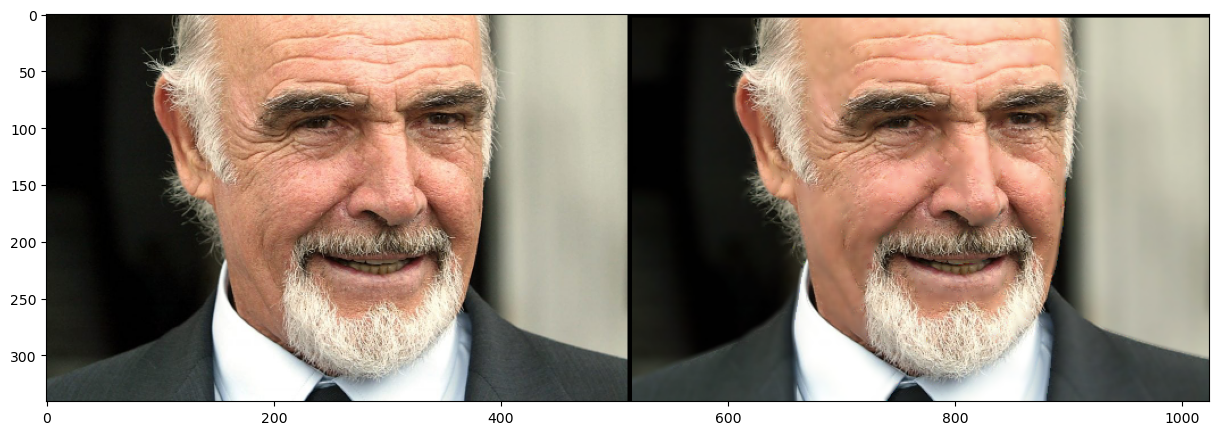

In [14]:
#display the result as an image
plt.figure(figsize=(15, 10))
result = cv.hconcat((img,img_blurred))
plt.imshow(result)